# Report

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## Iteration setup

**Import libraries**

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

import xarray as xr

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor   
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import  accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, auc, mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold


**Load datasets**

This study uses multiple datasets from reliable scientific and governmental sources. Weather data were obtained from the Royal Netherlands Meteorological Institute (KNMI), including measurements such as temperature, wind, precipitation, and radiation from several coastal stations in the Netherlands. Environmental data were sourced from Statistics Netherlands (CBS), specifically ecosystem type maps covering the period 2013–2022. In addition, species occurrence data for Clupea harengus (Atlantic herring) were retrieved from the Global Biodiversity Information Facility (GBIF), an international open-access biodiversity database.

In [4]:
df_clupea = pd.read_csv('Clupea harengus.csv', low_memory=False)
df_weather = pd.read_csv('knmi_weather_data.csv')
df_env = pd.read_csv('habitats_cbs_2022.csv')
ds = xr.open_dataset('water_temp_salt.nc', engine="netcdf4")

## Data understanding

In [5]:
df_water = ds.to_dataframe().reset_index()

column_mapping = {
    "time": "date",
    "latitude": "latitude",
    "longitude": "longitude",
    "mlotst": "mixed_layer_thickness",
    "thetao": "sea_water_temperature",
    "ubar": "eastward_depth_averaged_current",
    "vbar": "northward_depth_averaged_current",
    "uo": "eastward_ocean_current",
    "vo": "northward_ocean_current",
    "zos": "sea_surface_height"
}

df_water = df_water.rename(columns=column_mapping).copy()

**Clupea harengus summary statistics**

In [ ]:
df_clupea['eventDate'] = pd.to_datetime(df_clupea['eventDate'], format='%Y-%m-%d')
df_clupea['Clupea harengus'] = pd.to_numeric(df_clupea['Clupea harengus'], errors='coerce')

print('General information:')
print(df_clupea.info())

print('Summary statistics:')
print(df_clupea.describe())

print("\n\nAmount of null's in each column for Clupea Harengus dataset:")
print(df_clupea.isnull().sum())

General information:
<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Clupea harengus            float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 574.9 MB
None
Summary statistics:
       decimalLatitude  decimalLongitude                   eventDate  \
count     1.255879e+07      1.255879e+07                    12558786   
mean      5.222995e+01      5.532896e+00  2017-12-31 12:10:06.165595   
min       3.500000e+00      3.350000e+00         2010-01-01 00:00:00   
25%       5.170000e+01      4.900000e+00         2014-01-01 00:00:00   
50%       5.220000e+01      5.650000e+00    

**Water dataset summary statistics and fixes**

In [7]:
df_water_filtered = df_water[
    df_water["longitude"].between(3, 7) &
    df_water["latitude"].between(51, 53.5)
].copy()

print("\nGeneral information for water dataset:")
df_water.info()

print("\n\nStatistical summary for water dataset:")
print(df_water.describe())

print("\n\nDataset length:")
print(len(df_water_filtered))

df_water_filtered = df_water_filtered.rename(columns={
    "longitude": "decimalLongitude",
    "latitude": "decimalLatitude"
})

df_water_filtered = (
    df_water_filtered[
        ["decimalLongitude", "decimalLatitude", "sea_water_temperature", "date"]
    ]
    .dropna(subset=["sea_water_temperature"])
    .reset_index(drop=True)
)

daily_temp = (
    df_water_filtered
        .groupby(df_water_filtered["date"].dt.date)["sea_water_temperature"]
        .mean()
        .round(2)
        .reset_index()
        .rename(columns={
            "date": "eventDate",
            "sea_water_temperature": "mean_sea_water_temperature"
        })
)

print(daily_temp.head(10))


General information for water dataset:
<class 'pandas.DataFrame'>
RangeIndex: 21320448 entries, 0 to 21320447
Data columns (total 10 columns):
 #   Column                            Dtype         
---  ------                            -----         
 0   date                              datetime64[ns]
 1   latitude                          float32       
 2   longitude                         float32       
 3   mixed_layer_thickness             float32       
 4   sea_water_temperature             float32       
 5   eastward_depth_averaged_current   float32       
 6   eastward_ocean_current            float32       
 7   northward_depth_averaged_current  float32       
 8   northward_ocean_current           float32       
 9   sea_surface_height                float32       
dtypes: datetime64[ns](1), float32(9)
memory usage: 894.6 MB


Statistical summary for water dataset:
                                date      latitude     longitude  \
count                       21320448  

**Weather dataset summary statistics and fixes**

In [8]:
str_columns = df_weather.select_dtypes(include=['object', 'string']).columns

for col in str_columns:
    df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce')

df_weather['Date'] = pd.to_datetime(df_weather['Date'], format='%Y%m%d')

df_weather = df_weather.replace(r'^\s*$', pd.NA, regex=True)

print("General information:")
df_weather.info()

print("\n\nAmount of null's in each column:")
print(df_weather.isna().sum())

print("\n\nStatistical summary:")
df_weather.describe()

General information:
<class 'pandas.DataFrame'>
RangeIndex: 71784 entries, 0 to 71783
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Station                        71784 non-null  int64         
 1   Date                           71784 non-null  datetime64[us]
 2   vector_mean_direction_degrees  70421 non-null  float64       
 3   vector_mean_windspeed          70421 non-null  float64       
 4   windspeed                      70514 non-null  float64       
 5   windgust                       70498 non-null  float64       
 6   temp_mean                      35855 non-null  float64       
 7   temp_min                       35855 non-null  float64       
 8   temp_max                       35855 non-null  float64       
 9   sun_dur                        29906 non-null  float64       
 10  per_max_pot_sun_dur            29906 non-null  float64       
 11  globa

,Station,Date,vector_mean_direction_degrees,vector_mean_windspeed,windspeed,windgust,temp_mean,temp_min,temp_max,sun_dur,per_max_pot_sun_dur,global_radiation,precipitation_dur,precipitation,cloud_cover
count,71784.000000,71784,70421.000000,70421.000000,70514.000000,70498.000000,35855.000000,35855.000000,35855.000000,29906.000000,29906.000000,29906.000000,29907.000000,29907.000000,19291.000000
mean,274.750000,2018-03-10 12:00:00,190.671490,59.356769,67.406132,132.244319,109.198857,80.477925,137.794338,53.724069,41.440012,1107.955527,17.106697,22.103454,5.686693
min,209.000000,2010-01-01 00:00:00,1.000000,0.000000,10.000000,30.000000,-114.000000,-176.000000,-67.000000,-1.000000,0.000000,22.000000,0.000000,-1.000000,0.000000
25%,240.250000,2014-02-04 00:00:00,110.000000,36.000000,45.000000,100.000000,67.000000,42.000000,89.000000,14.000000,13.000000,337.250000,0.000000,0.000000,4.000000
50%,281.000000,2018-03-10 12:00:00,210.000000,56.000000,63.000000,120.000000,106.000000,79.000000,135.000000,48.000000,40.000000,935.000000,2.000000,1.000000,6.000000
75%,310.500000,2022-04-14 00:00:00,258.000000,79.000000,85.000000,160.000000,156.000000,125.000000,188.000000,87.000000,68.000000,1770.000000,24.000000,24.000000,8.000000
max,330.000000,2026-05-18 00:00:00,360.000000,202.000000,203.000000,480.000000,303.000000,236.000000,389.000000,157.000000,95.000000,3180.000000,240.000000,780.000000,8.000000
std,39.132793,NaN,95.306002,30.438256,28.593083,47.734481,57.372641,54.645667,64.412893,43.248569,30.372459,838.851918,28.085692,45.114325,2.241838


| Station | LON (east) | LAT (north) | ALT (m) | Name               |
| ------- | ---------- | ----------- | ------- | ------------------ |
| 209     | 4.518      | 52.465      | 0.00    | IJmond             |
| 225     | 4.555      | 52.463      | 4.40    | IJmuiden           |
| 235     | 4.781      | 52.928      | 1.20    | De Kooy Airport    |
| 242     | 4.921      | 53.241      | 10.80   | Vlieland Vliehors  |
| 251     | 5.346      | 53.392      | 0.70    | Hoorn Terschelling |
| 277     | 6.200      | 53.413      | 2.90    | Lauwersoog         |
| 285     | 6.399      | 53.575      | 0.00    | Huibertgat         |
| 308     | 3.379      | 51.381      | 0.00    | Cadzand            |
| 310     | 3.596      | 51.442      | 8.00    | Vlissingen         |
| 312     | 3.622      | 51.768      | 0.00    | Oosterschelde      |
| 313     | 3.242      | 51.505      | 0.00    | Vlakte van De Raan |
| 330     | 4.122      | 51.992      | 11.90   | Hoek van Holland   |

In [ ]:
daily_temp['eventDate'] = pd.to_datetime(daily_temp['eventDate'])

daily_temp['eventDate'] = daily_temp['eventDate'].dt.normalize()

df_weather['Date'] = df_weather['Date'].dt.normalize()

df_weather = df_weather.merge(
    daily_temp,
    left_on='Date',
    right_on='eventDate',
    how='left',
    validate='many_to_one'
)

df_weather = df_weather.drop(columns=['eventDate'])

**Imputation**

In [10]:
df_weather = df_weather.ffill()
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 71784 entries, 0 to 71783
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Station                        71784 non-null  int64         
 1   Date                           71784 non-null  datetime64[us]
 2   vector_mean_direction_degrees  71784 non-null  float64       
 3   vector_mean_windspeed          71784 non-null  float64       
 4   windspeed                      71784 non-null  float64       
 5   windgust                       71784 non-null  float64       
 6   temp_mean                      71784 non-null  float64       
 7   temp_min                       71784 non-null  float64       
 8   temp_max                       71784 non-null  float64       
 9   sun_dur                        71784 non-null  float64       
 10  per_max_pot_sun_dur            71784 non-null  float64       
 11  global_radiation          

### Merge datasets

**Merge Clupea harengus dataset with habitat dataset**

In [11]:
df_merged = pd.merge(
    df_clupea,
    df_env,
    on=['decimalLatitude', 'decimalLongitude'],
    how='left'
)

**Merge weather data set**

Calculate the closest station to the observation and use weather data from that station

In [12]:
weather_daily = df_weather.groupby('Date').mean(numeric_only=True).reset_index()

stations = pd.DataFrame({
    'Station': [209, 225, 235, 242, 251, 277, 285, 308, 310, 312, 313, 330],
    'LON':     [4.518, 4.555, 4.781, 4.921, 5.346, 6.200, 6.399, 3.379, 3.596, 3.622, 3.242, 4.122],
    'LAT':     [52.465, 52.463, 52.928, 53.241, 53.392, 53.413, 53.575, 51.381, 51.442, 51.768, 51.505, 51.992]
})

grids = df_merged[['decimalLatitude', 'decimalLongitude']].drop_duplicates().copy()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def nearest_station(lat, lon, stations_df):
    dists = haversine(lat, lon, stations_df['LAT'].values, stations_df['LON'].values)
    idx = np.argmin(dists)
    return pd.Series({
        'nearest_station': stations_df.iloc[idx]['Station'],
        'station_distance_km': dists[idx]
    })

grids[['nearest_station', 'station_distance_km']] = (
    grids.apply(lambda row: nearest_station(row['decimalLatitude'], row['decimalLongitude'], stations), axis=1)
)

In [13]:
df_merged = df_merged.merge(
    grids,
    on=['decimalLatitude', 'decimalLongitude'],
    how='left',
    validate='many_to_one'
)

df_merged = df_merged.merge(
    df_weather,
    left_on=['nearest_station', 'eventDate'],
    right_on=['Station', 'Date'],
    how='left',
    validate='many_to_one'
)

In [14]:
df_merged.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Clupea harengus,agricultural,built,coast,forest,...,temp_mean,temp_min,temp_max,sun_dur,per_max_pot_sun_dur,global_radiation,precipitation_dur,precipitation,cloud_cover,mean_sea_water_temperature
0,50.75,5.65,2010-01-01,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,6.0,-15.0,19.0,66.0,83.0,455.0,0.0,0.0,3.0,7.12
1,50.75,5.65,2010-01-02,26.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,12.0,-4.0,22.0,18.0,23.0,229.0,56.0,47.0,7.0,7.12
2,50.75,5.65,2010-01-03,3.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,-15.0,-29.0,21.0,70.0,88.0,476.0,19.0,15.0,2.0,7.12
3,50.75,5.65,2010-01-04,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,-4.0,-34.0,37.0,12.0,15.0,224.0,8.0,2.0,7.0,7.12
4,50.75,5.65,2010-01-05,0.0,0,0.0,1.7747,0.0568,0.0,0.0616,...,5.0,-14.0,29.0,42.0,52.0,294.0,0.0,0.0,6.0,7.12


**Create sub datasets for visualizations**

In [15]:
df_merged_to = df_merged[df_merged['total_observations'].fillna(0) != 0]
df_merged_so = df_merged[df_merged['speciesgroup_observations'].fillna(0) != 0]
df_merged_ch = df_merged[df_merged['Clupea harengus'].fillna(0) != 0]

df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 33 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   decimalLatitude                float64       
 1   decimalLongitude               float64       
 2   eventDate                      datetime64[us]
 3   total_observations             float64       
 4   speciesgroup_observations      int64         
 5   Clupea harengus                float64       
 6   agricultural                   float64       
 7   built                          float64       
 8   coast                          float64       
 9   forest                         float64       
 10  other                          float64       
 11  sand/heather                   float64       
 12  water                          float64       
 13  wetland                        float64       
 14  main_habitat                   str           
 15  nearest_station         

In [16]:
cond_south = (df_merged['decimalLatitude'] < 51.8) & (df_merged['decimalLongitude'] <= 4.25)

cond_mid = (df_merged['decimalLatitude'] >= 51.8) & (df_merged['decimalLatitude'] < 52.8) & \
           (df_merged['decimalLongitude'] <= (4.2 + (df_merged['decimalLatitude'] - 51.8) * 0.7))

cond_north = (df_merged['decimalLatitude'] >= 52.8) & \
             ((df_merged['decimalLongitude'] < 5.0) | (df_merged['decimalLatitude'] >= 53.2))

df_merged_coastal_marine = df_merged[cond_south | cond_mid | cond_north].copy()

print(f"Original rows: {len(df_merged)}")
print(f"Coastal/Marine rows: {len(df_merged_coastal_marine)}")
(df_merged_coastal_marine["Clupea harengus"]>0).sum()

Original rows: 12558786
Coastal/Marine rows: 2945376


np.int64(1977)

---

## Visualizations

**Clupe harengus observations over the years**

Mean:  2.625183733463988
Median:  1.0


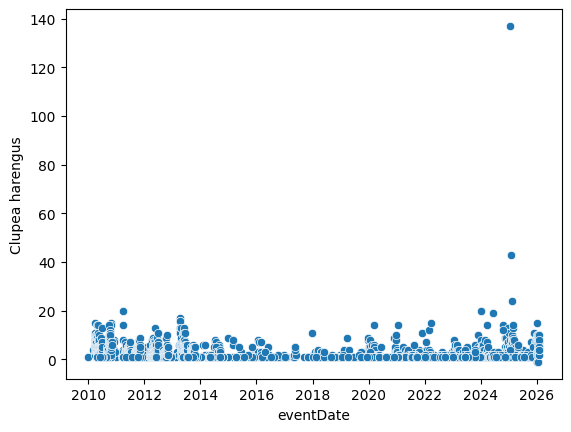

In [17]:
sns.scatterplot(df_merged_ch, y='Clupea harengus', x='eventDate')
print("Mean: ", df_merged_ch['Clupea harengus'].mean())
print("Median: ", df_merged_ch['Clupea harengus'].median())

**Clupea harengus sightings across netherlands**

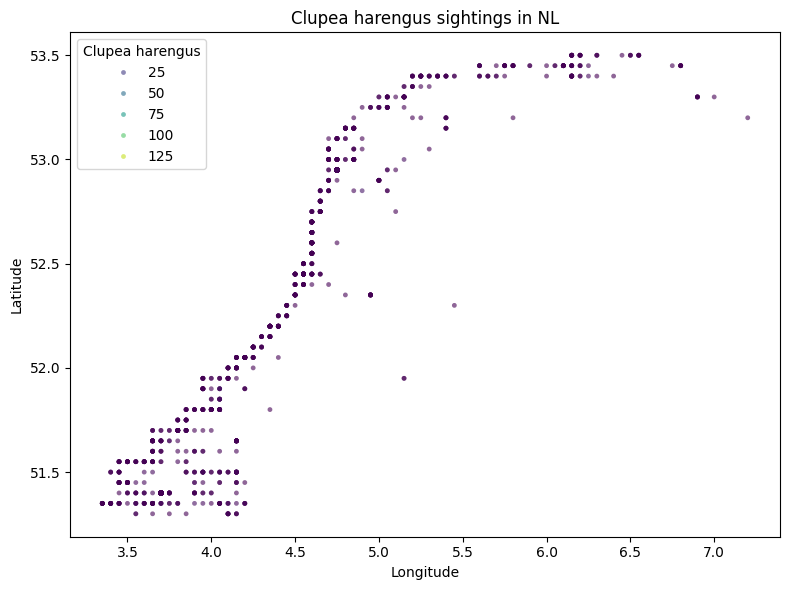

In [18]:
loc_sample = df_merged_ch[
    (df_merged_ch['Clupea harengus']>0) &
    (df_merged_ch['decimalLongitude'].between(3.0, 7.5)) &
    (df_merged_ch['decimalLatitude'].between(50.5, 53.7))
][['decimalLongitude', 'decimalLatitude', 'Clupea harengus']].dropna()

loc_sample = loc_sample.sample(
    n=min(2000, len(loc_sample)),
    random_state=69
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=loc_sample,
    x='decimalLongitude',
    y='decimalLatitude',
    hue='Clupea harengus',
    palette='viridis',
    s=12,
    alpha=0.6,
    linewidth=0
)

plt.title('Clupea harengus sightings in NL')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

**Observer Bias**

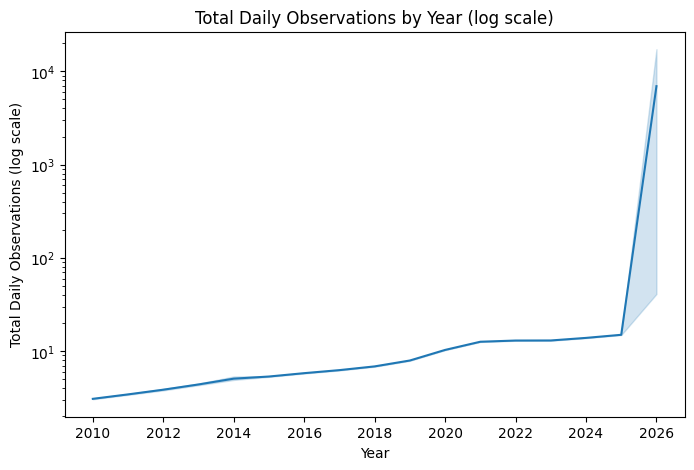

In [19]:
df_clupea['year'] = df_clupea['eventDate'].dt.year
year_counts = df_clupea['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_clupea,
    x='year',
    y='total_observations'
)

plt.yscale('log')

plt.title('Total Daily Observations by Year (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Year')

plt.show()

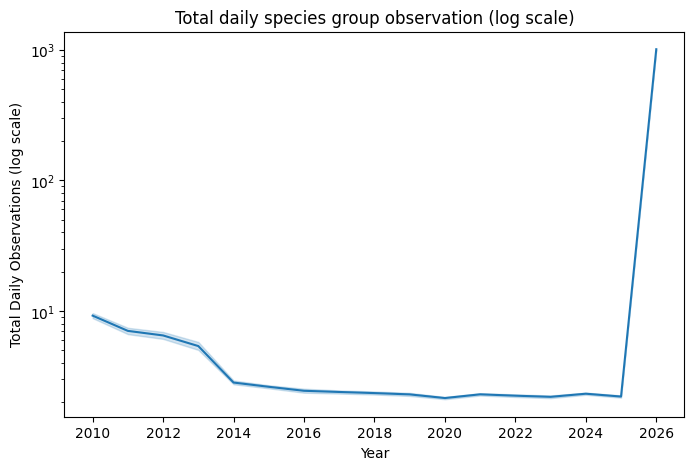

In [20]:
df_merged_so['year'] = df_merged_so['eventDate'].dt.year
year_counts = df_merged_so['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_merged_so,
    x='year',
    y='speciesgroup_observations'
)

plt.yscale('log')

plt.title('Total daily species group observation (log scale)')
plt.ylabel('Total Daily Observations (log scale)')
plt.xlabel('Year')

plt.show()

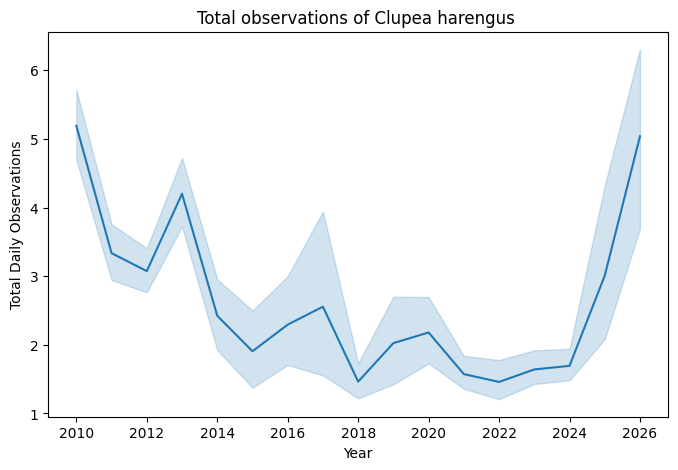

In [ ]:
df_merged_ch['year'] = df_merged_ch['eventDate'].dt.year
year_counts = df_merged_ch['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_merged_ch,
    x='year',
    y='Clupea harengus'
)

plt.title('Total observations of Clupea harengus ')
plt.ylabel('Total Daily Observations')
plt.xlabel('Year')

plt.show()

**Seasonal bias**

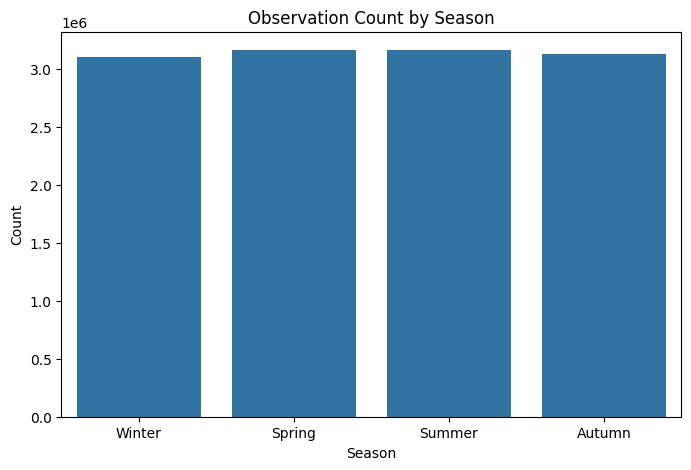

In [22]:
df_clupea['season'] = df_clupea['eventDate'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

season_counts = df_clupea['season'].value_counts()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_order,
    y=[season_counts[s] for s in season_order]
)

plt.title('Observation Count by Season')
plt.ylabel('Count')
plt.xlabel('Season')

plt.show()

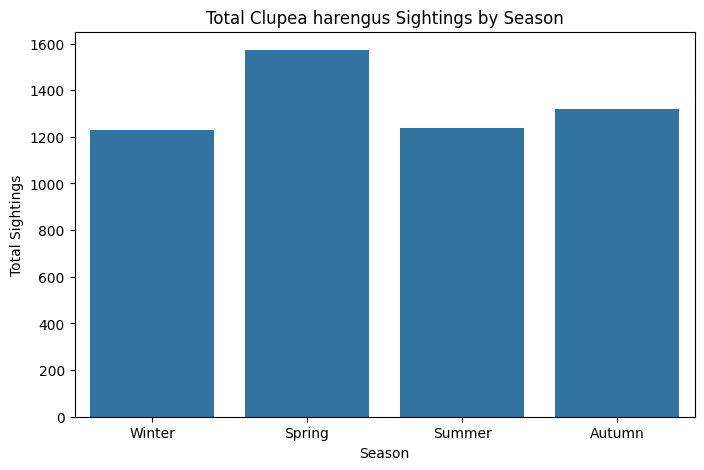

In [ ]:
df_clupea['season'] = df_clupea['eventDate'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

season_sightings = df_clupea.groupby('season')['Clupea harengus'].sum()

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_order,
    y=[season_sightings[s] for s in season_order]
)

plt.title('Total Clupea harengus Sightings by Season')
plt.ylabel('Total Sightings')
plt.xlabel('Season')

plt.show()

This tell us that there isn't more observer effort during seasons, yet there are more sightings during spring and autumn. This correlates with Clupea harrengus breeding seasons.

**Location bias**

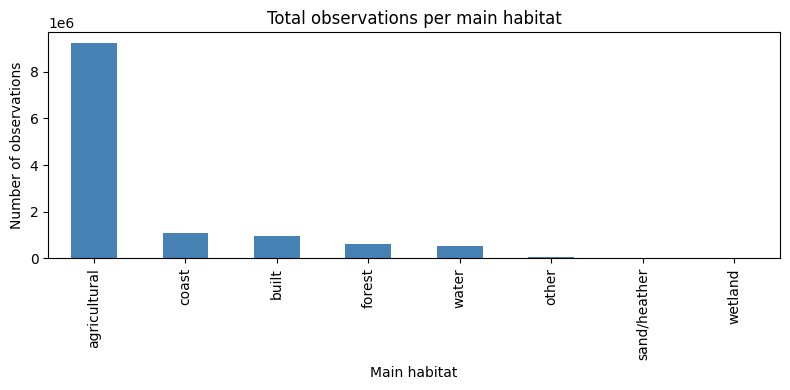

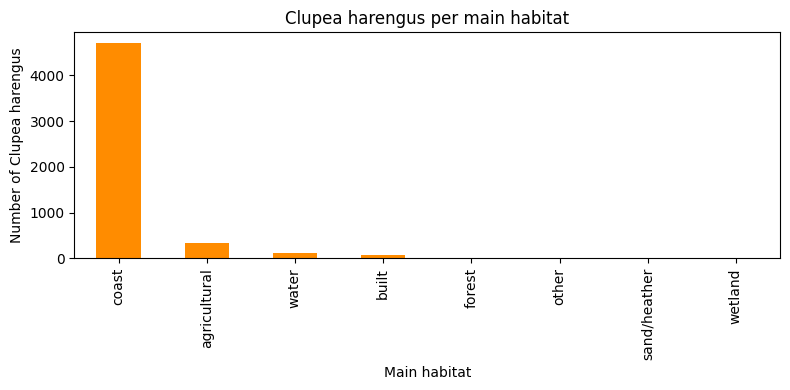

In [ ]:
obs_per_habitat = (
    df_merged
        .groupby('main_habitat')
        .size()
        .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
obs_per_habitat.plot(kind='bar', color='steelblue')
plt.ylabel('Number of observations')
plt.xlabel('Main habitat')
plt.title('Total observations per main habitat')
plt.tight_layout()
plt.show()

ch_per_habitat = (
    df_merged
        .groupby('main_habitat')['Clupea harengus']
        .sum()
        .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
ch_per_habitat.plot(kind='bar', color='darkorange')
plt.ylabel('Number of Clupea harengus')
plt.xlabel('Main habitat')
plt.title('Clupea harengus per main habitat')
plt.tight_layout()
plt.show()

### Non linear correlations

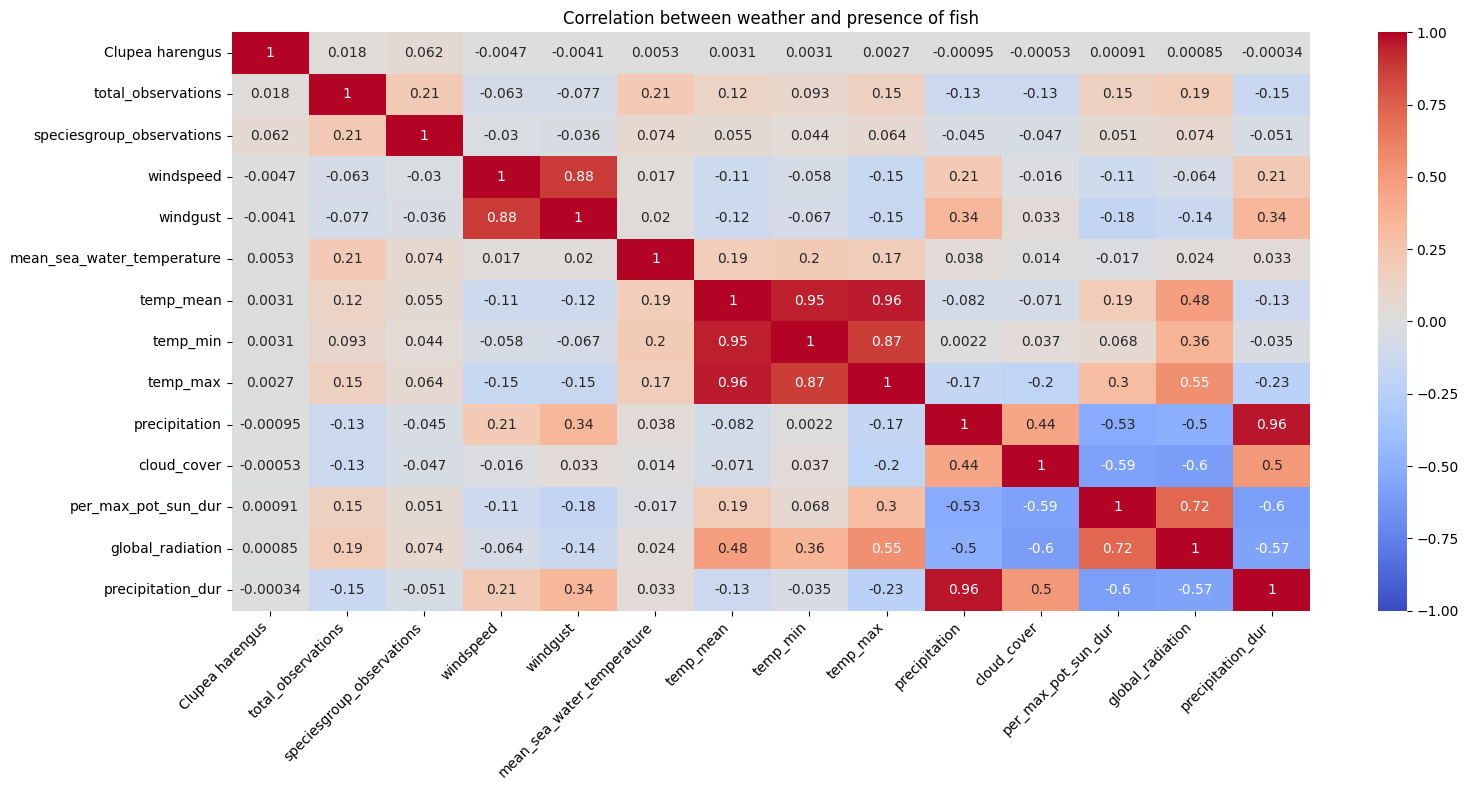

In [26]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

corr_df = df_merged[corr_cols]

plt.figure(figsize=(16,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Correlation between weather and presence of fish')
plt.tight_layout()
plt.show()

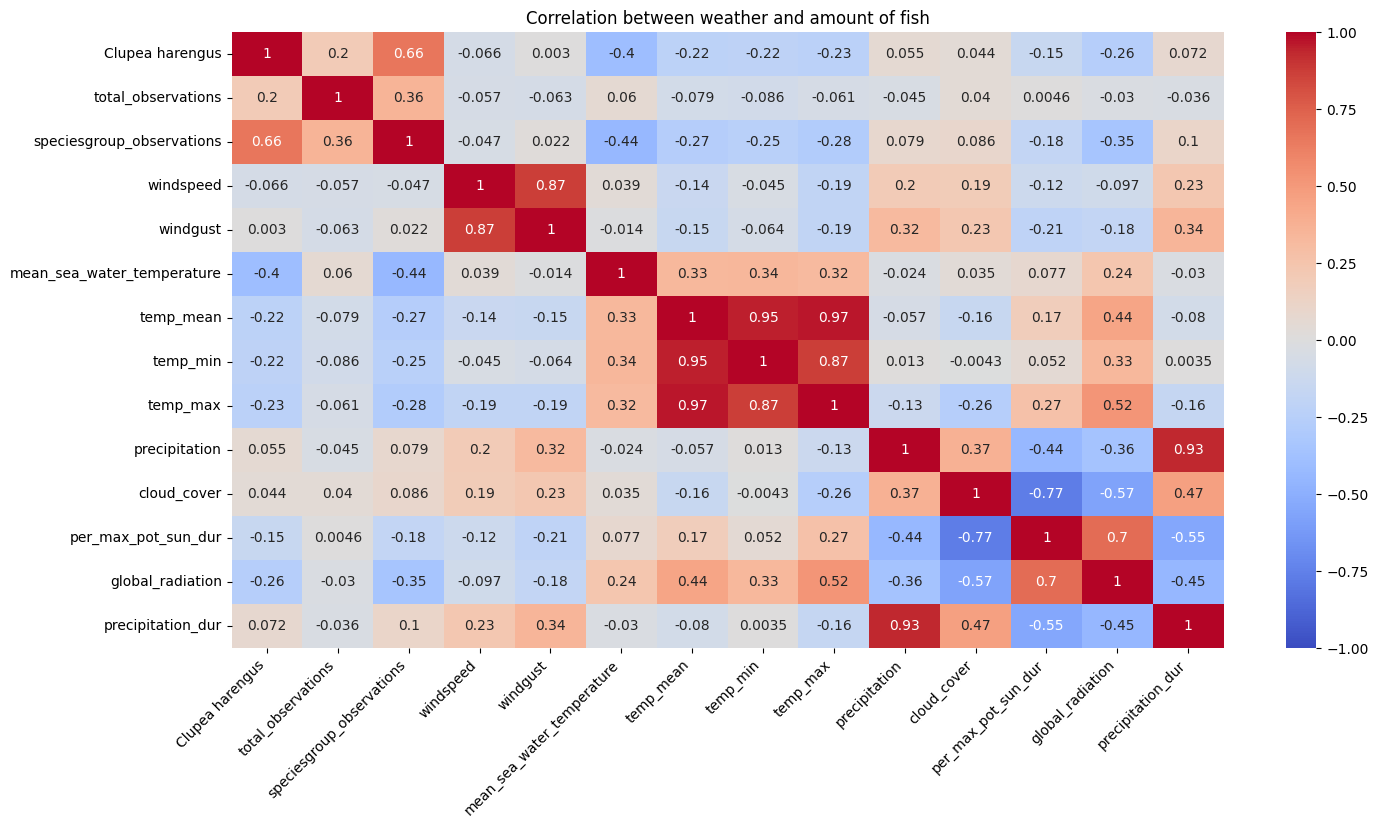

In [27]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',	'global_radiation',	'precipitation_dur'	
]

corr_df = df_merged_ch[corr_cols]

plt.figure(figsize=(16,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('Correlation between weather and amount of fish')
plt.show()

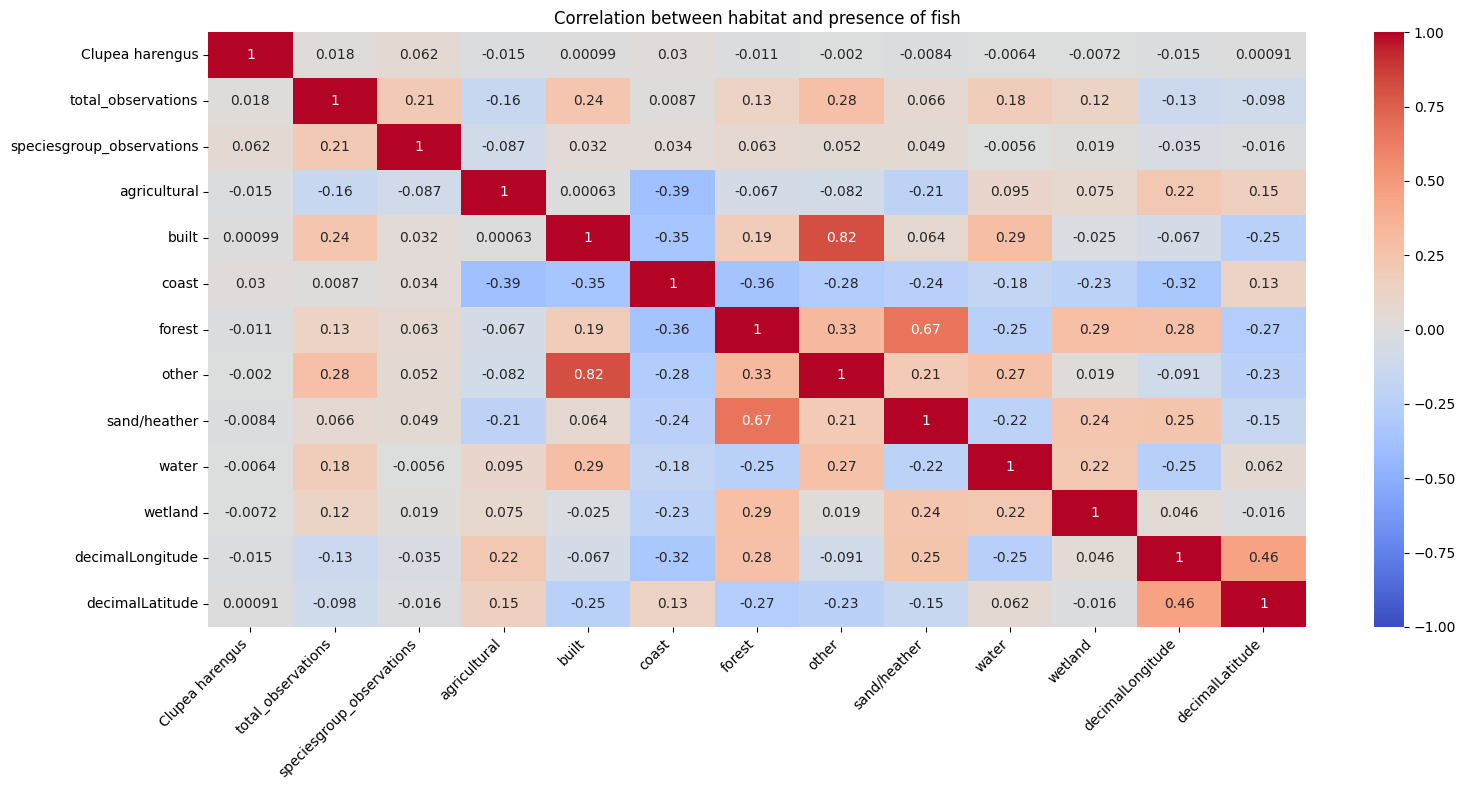

In [28]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland',
    'decimalLongitude',
    'decimalLatitude'
]

corr_df = df_merged[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(16,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('Correlation between habitat and presence of fish')
plt.tight_layout()
plt.show()

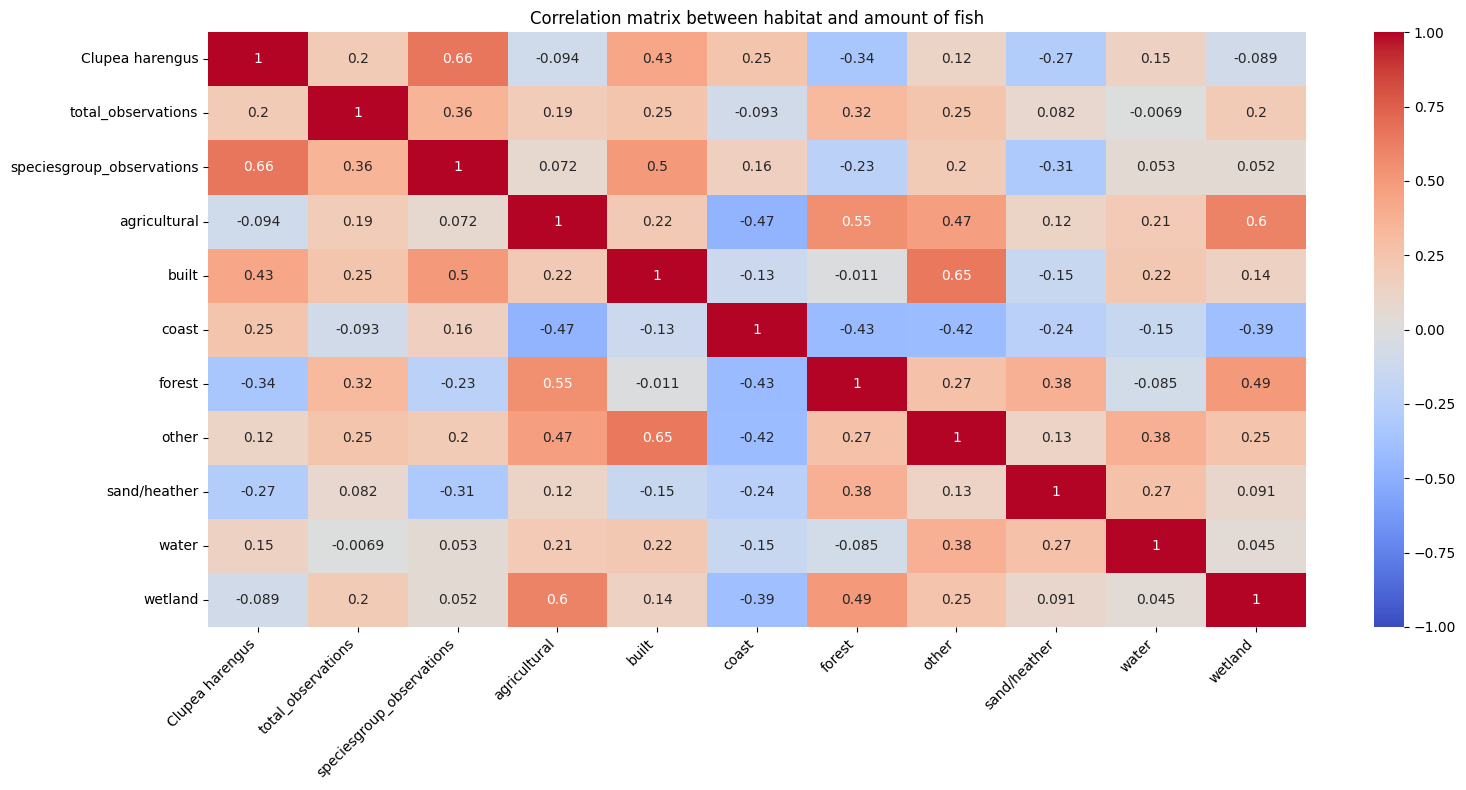

In [29]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland'
]

corr_df = df_merged_ch[corr_cols].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(16,8))

ax = sns.heatmap(
    corr_df.corr(method='spearman'),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('Correlation matrix between habitat and amount of fish')
plt.tight_layout()
plt.show()

### Linear correlations

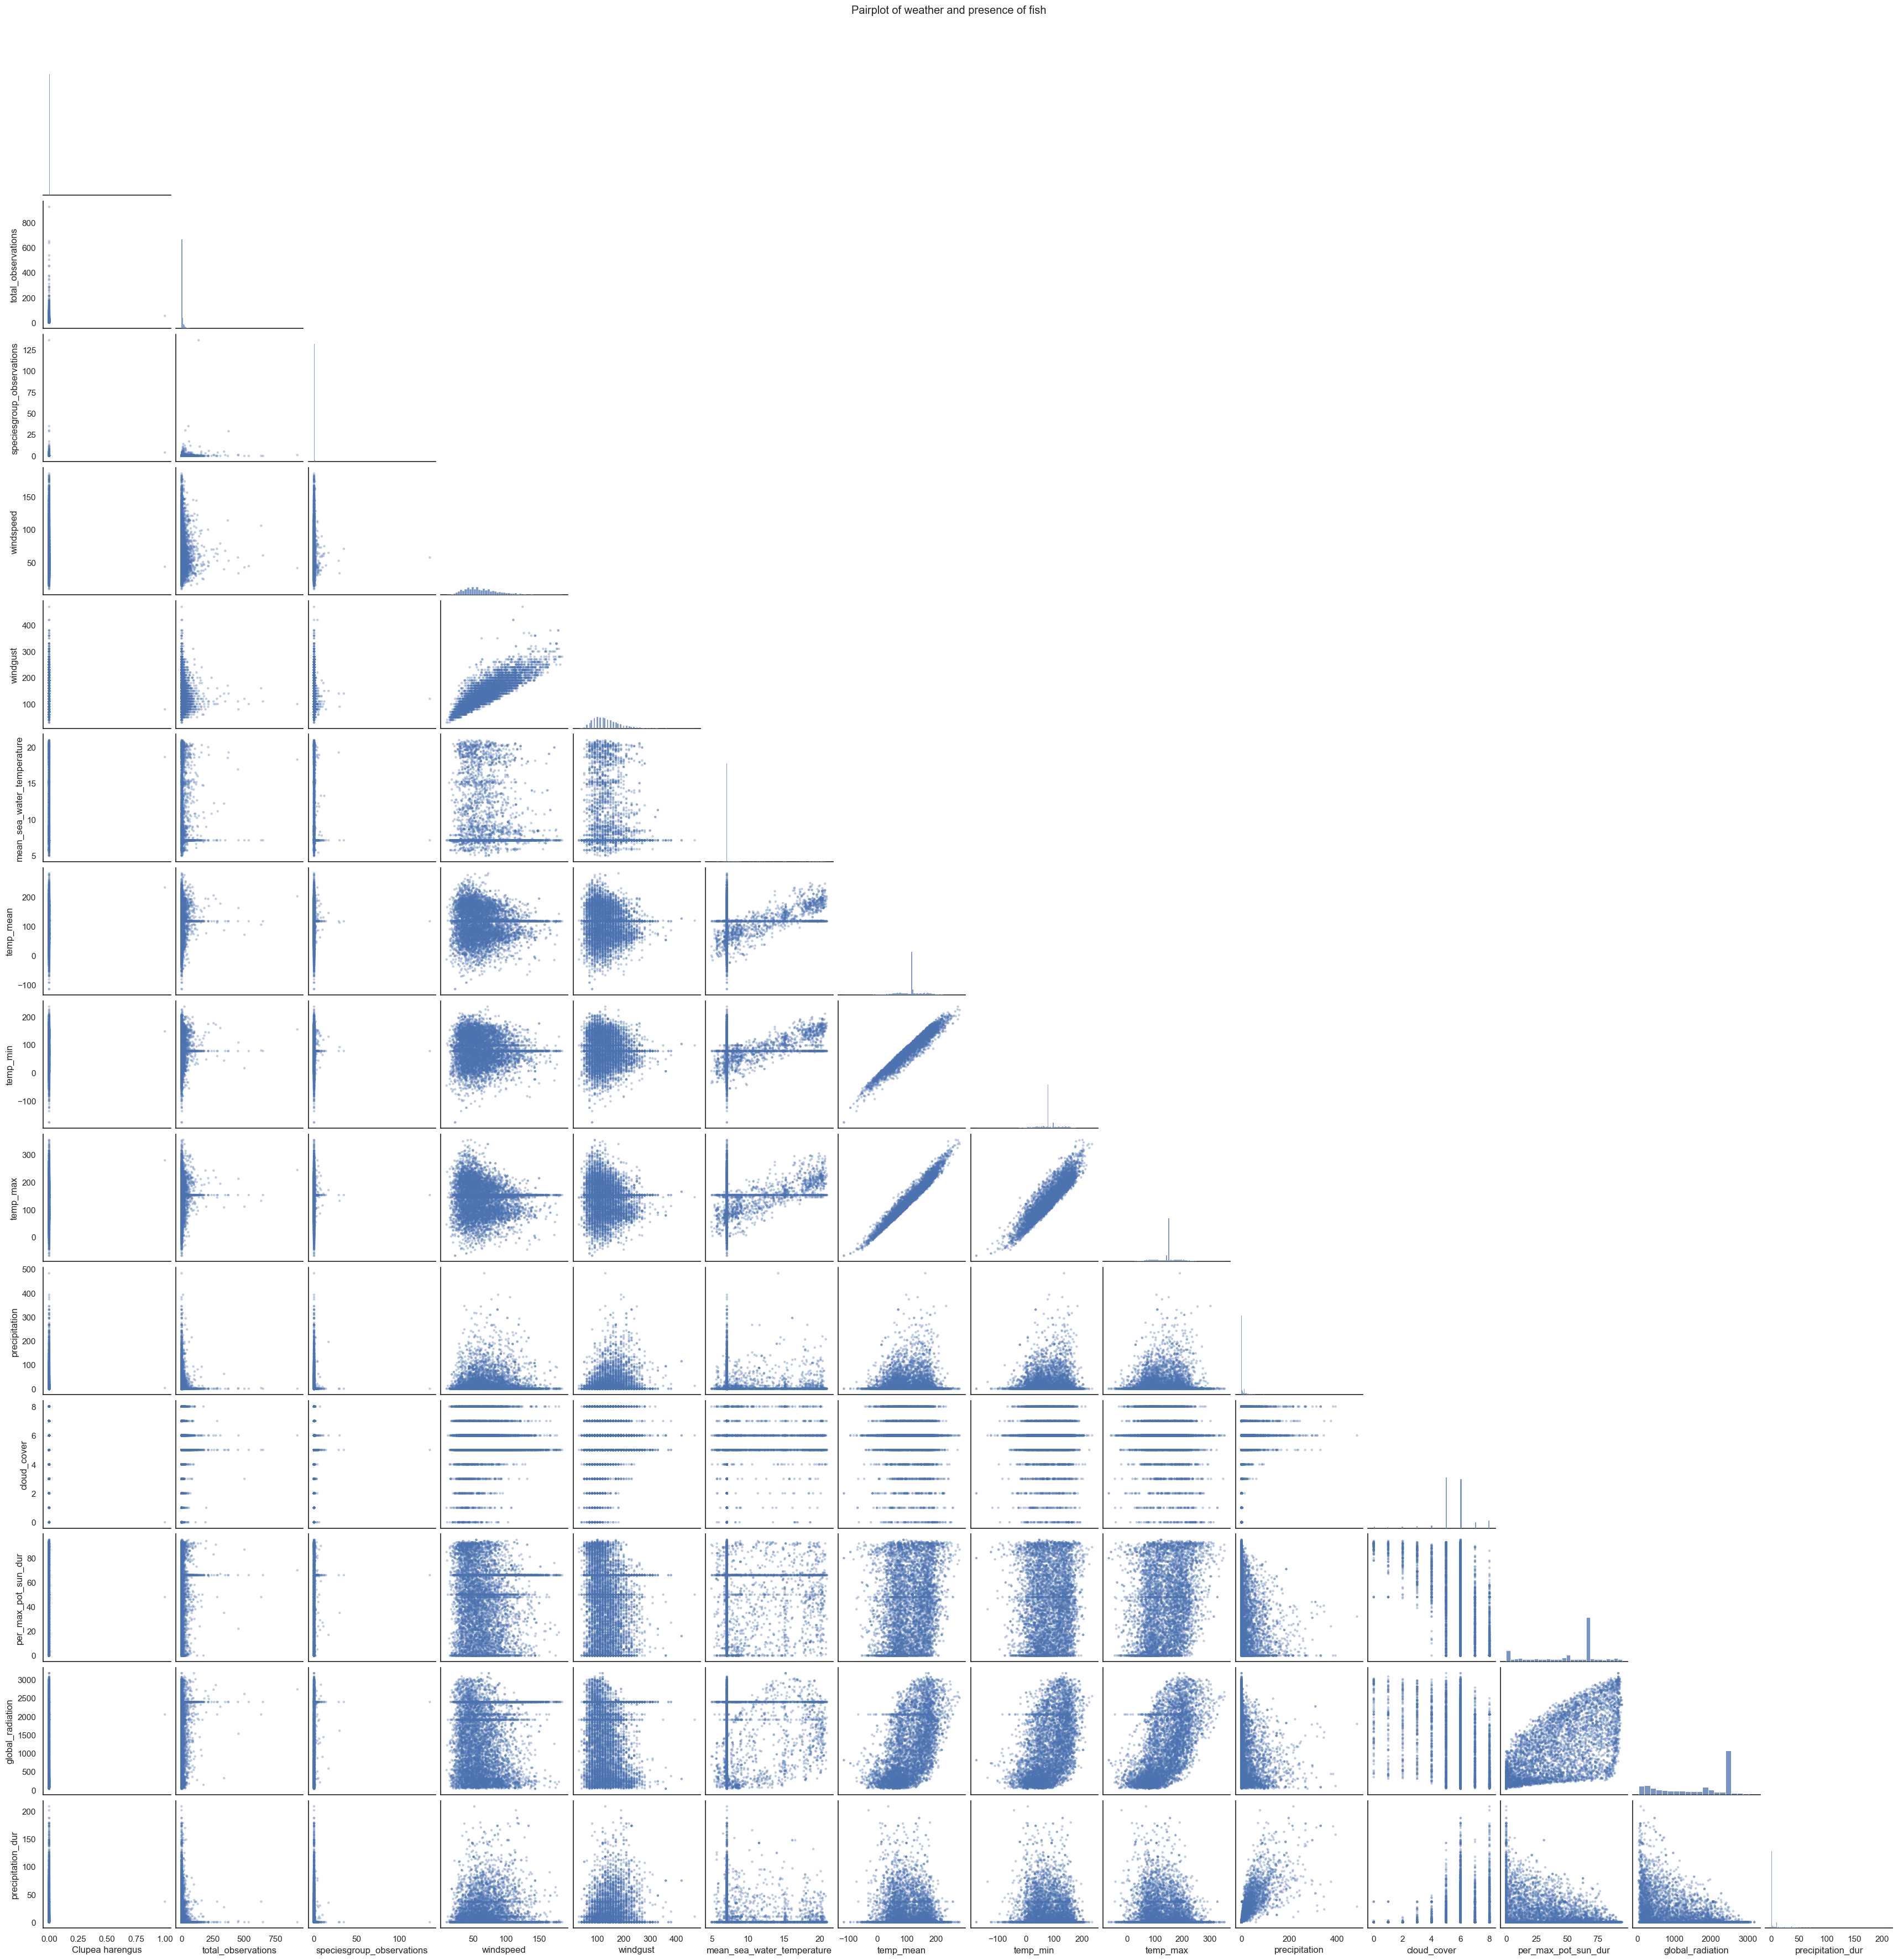

In [30]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',
    'global_radiation',
    'precipitation_dur'
]

pair_df = (
    df_merged[corr_cols]
    .dropna()
    .sample(n=min(10000, len(df_merged[corr_cols].dropna())), random_state=42)
)

sns.set_theme(style="white")
g = sns.pairplot(
    pair_df,
    corner=True,
    plot_kws={"s": 10, "alpha": 0.35, "edgecolor": "none"},
    diag_kws={"fill": True}
)

g.figure.suptitle("Pairplot of weather and presence of fish", y=1.02)
plt.show()

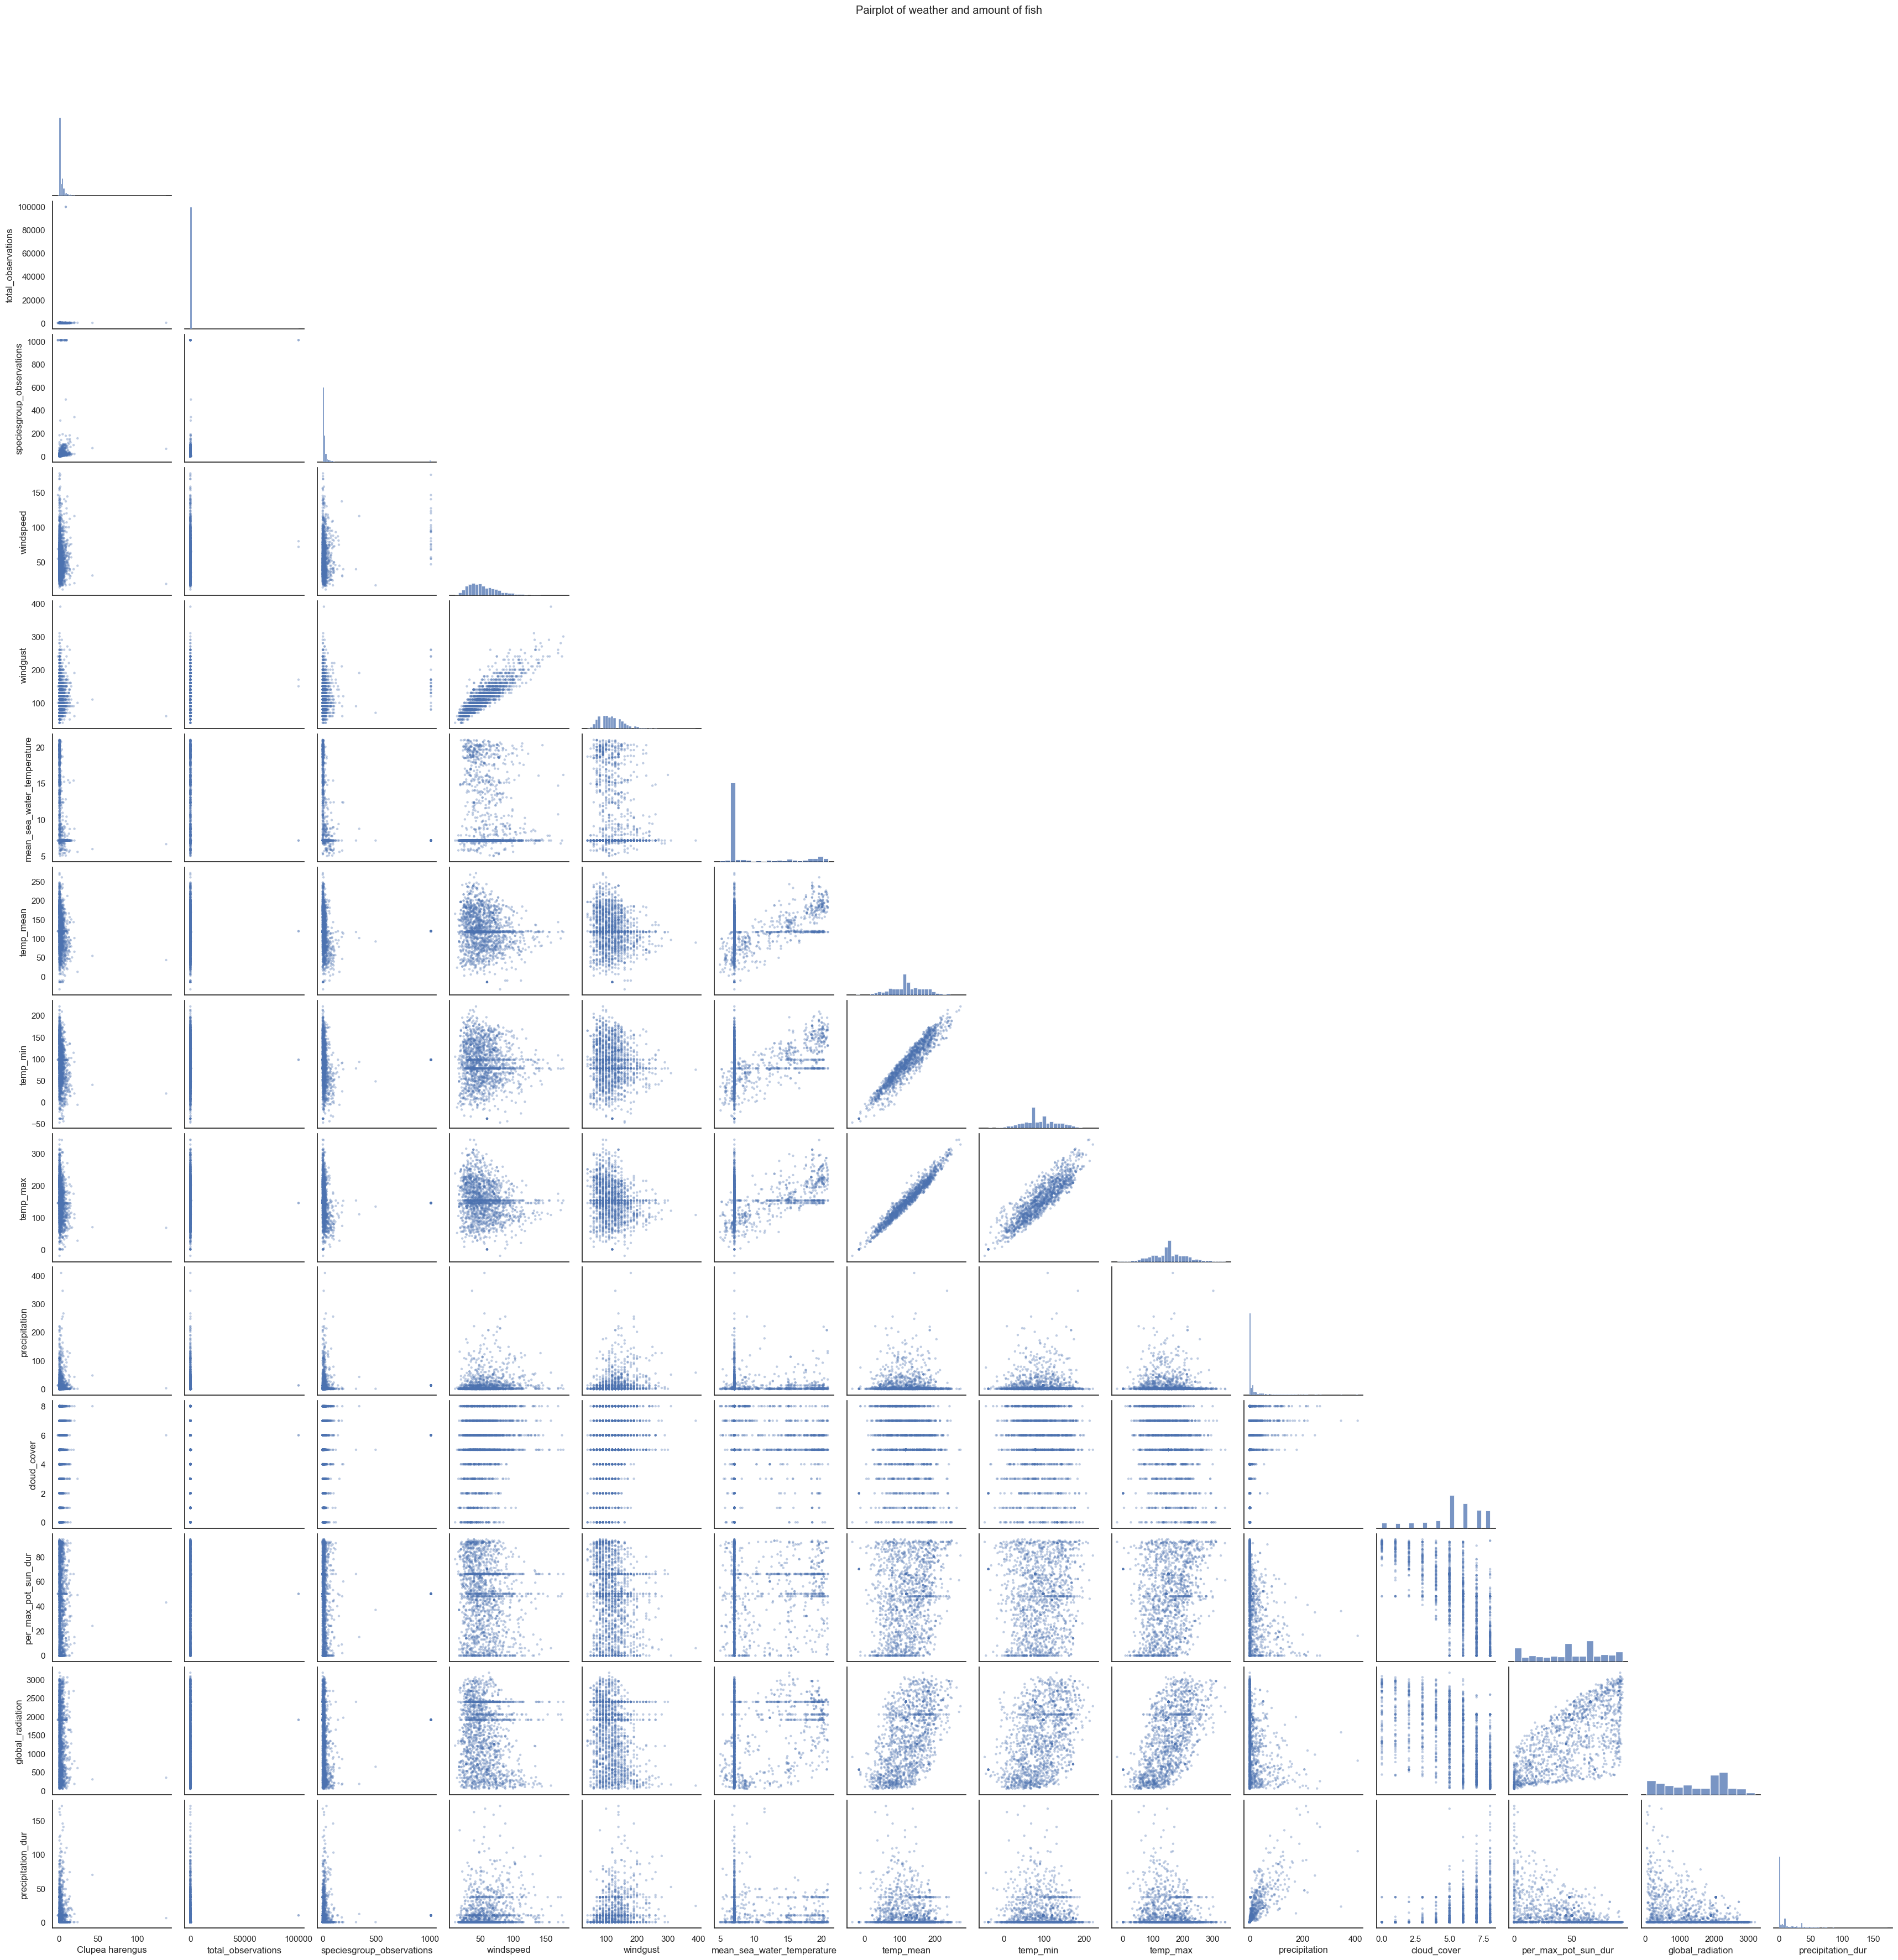

In [31]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',
    'global_radiation',
    'precipitation_dur'
]

pair_df = (
    df_merged_ch[corr_cols]
    .dropna()
    .sample(n=min(10000, len(df_merged_ch[corr_cols].dropna())), random_state=42)
)

sns.set_theme(style="white")
g = sns.pairplot(
    pair_df,
    corner=True,
    plot_kws={"s": 10, "alpha": 0.35, "edgecolor": "none"},
    diag_kws={"fill": True}
)

g.figure.suptitle("Pairplot of weather and amount of fish", y=1.02)
plt.show()

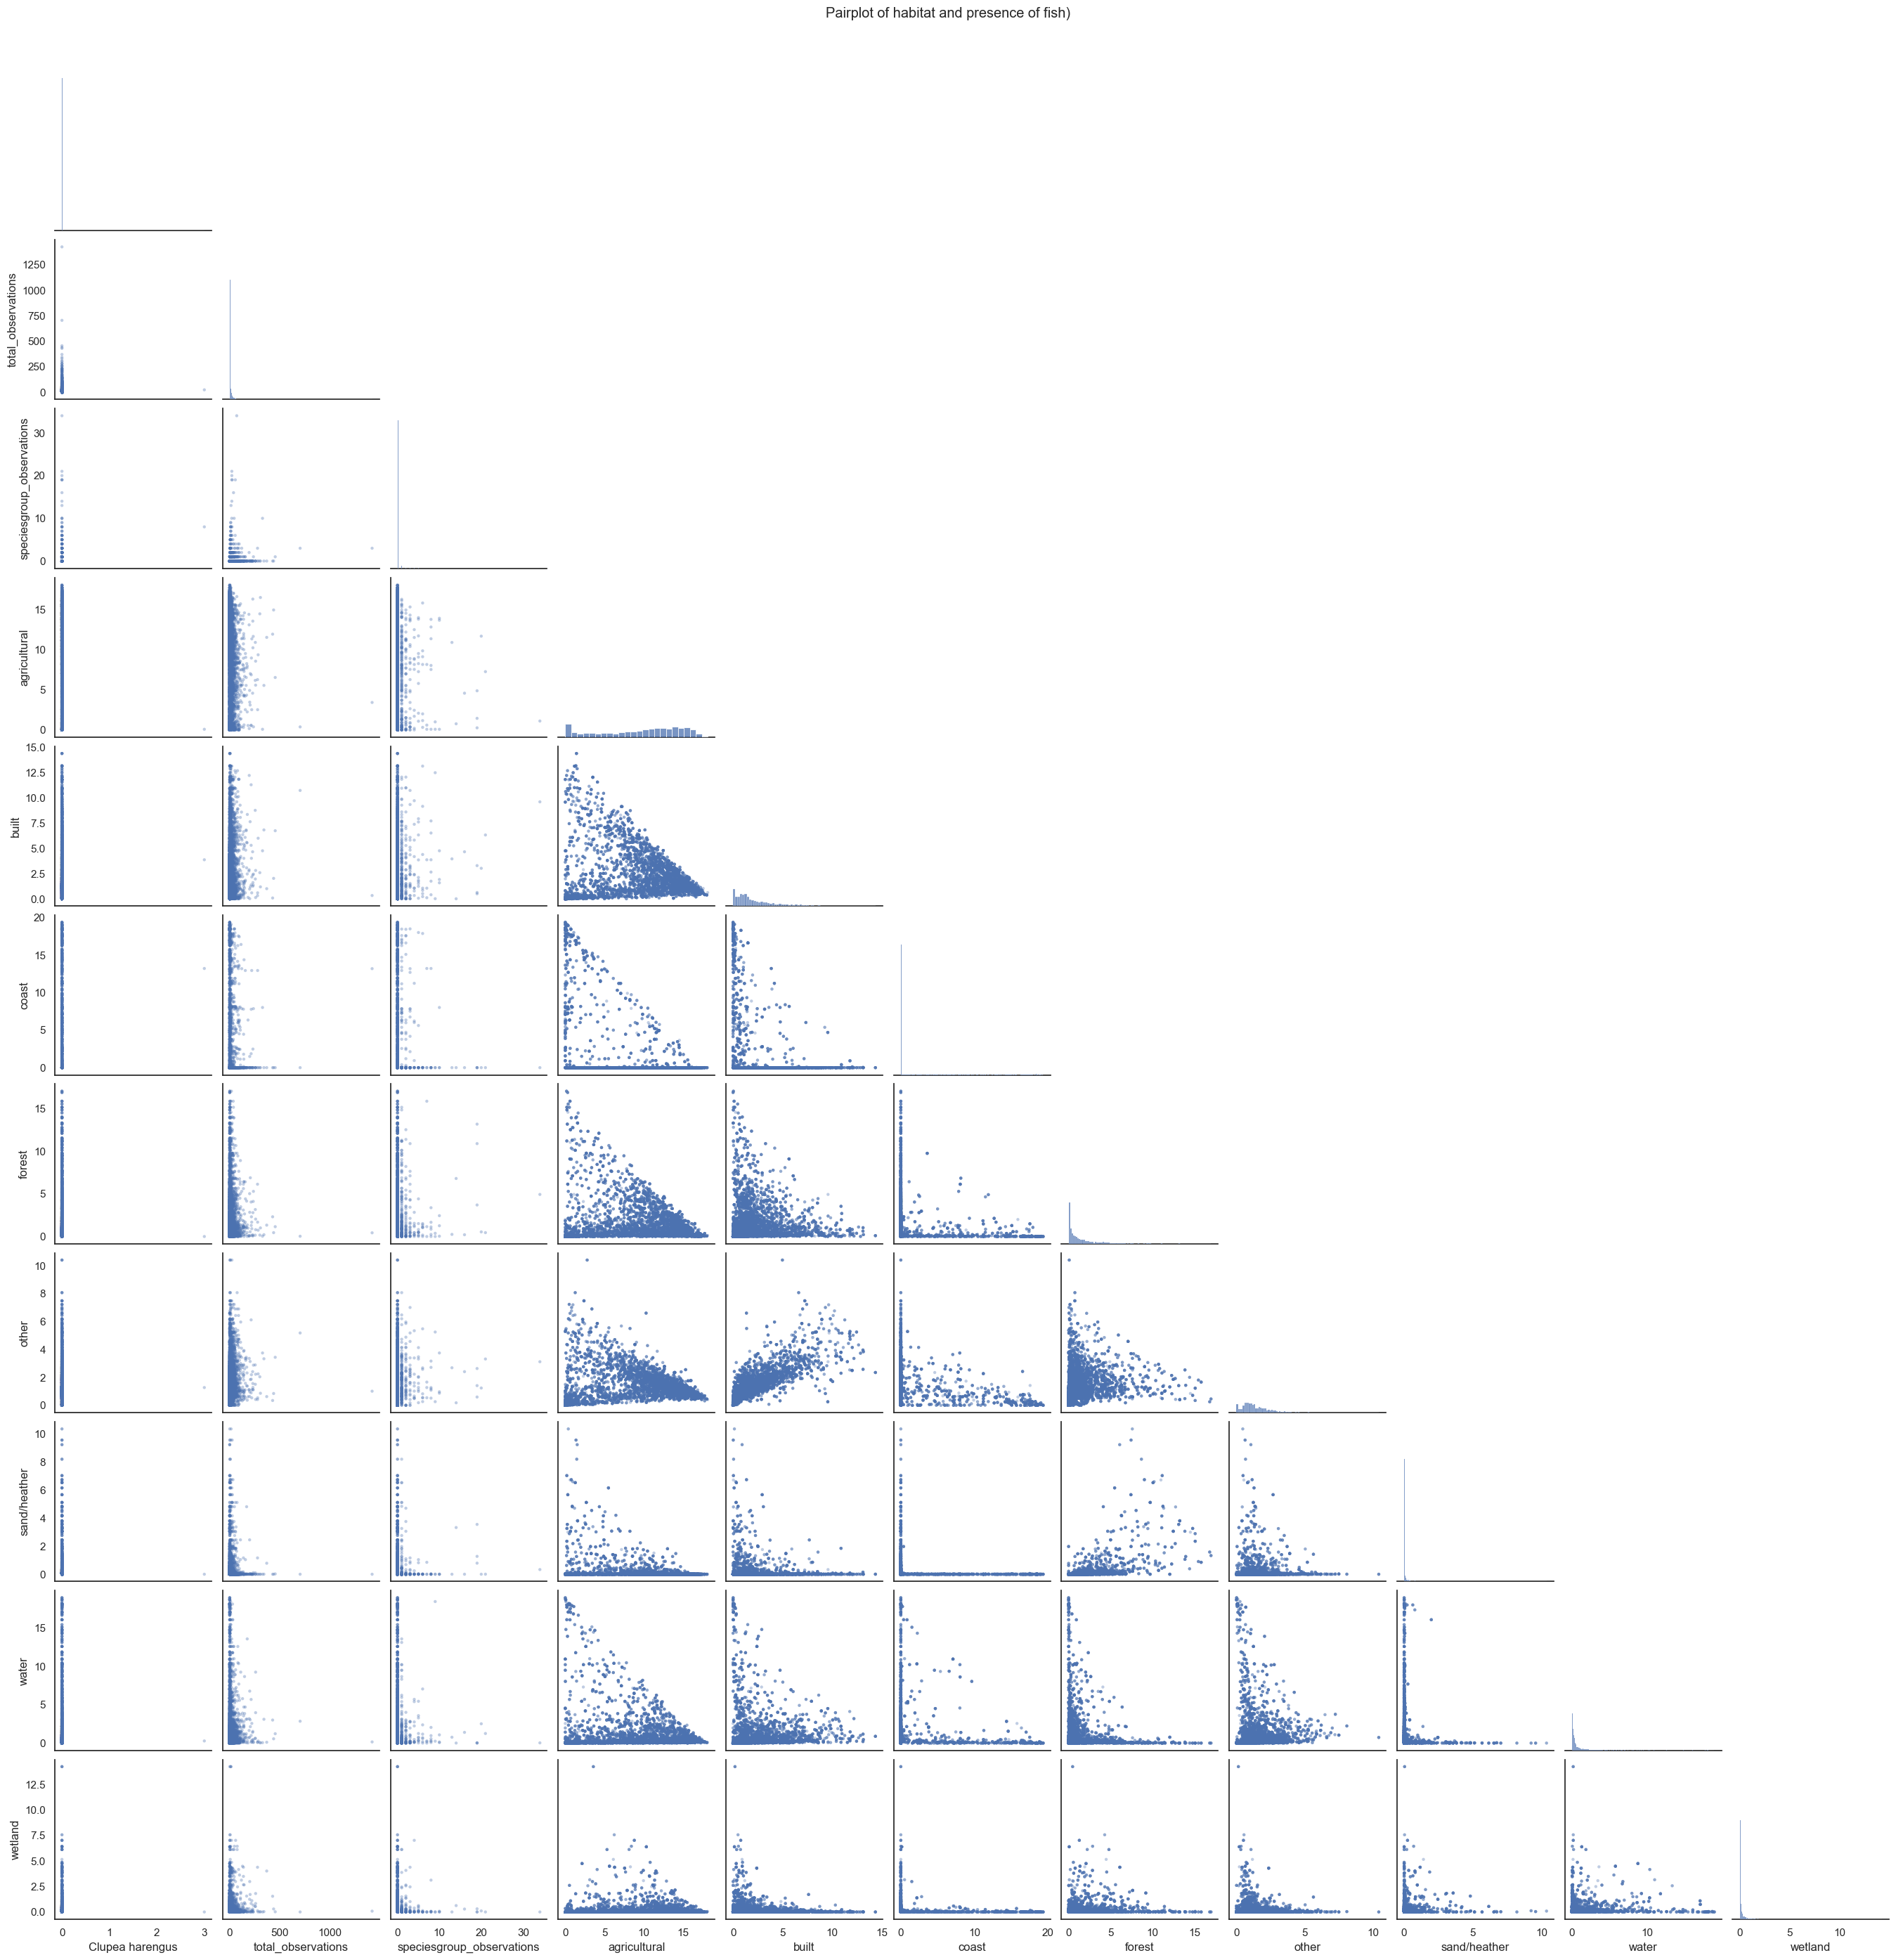

In [32]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland'
]

pair_df = (
    df_merged[corr_cols]
    .dropna()
    .sample(n=min(10000, len(df_merged[corr_cols].dropna())), random_state=42)
)

sns.set_theme(style="white")
g = sns.pairplot(
    pair_df,
    corner=True,
    plot_kws={"s": 10, "alpha": 0.35, "edgecolor": "none"},
    diag_kws={"fill": True}
)

g.figure.suptitle("Pairplot of habitat and presence of fish)", y=1.02)
plt.show()

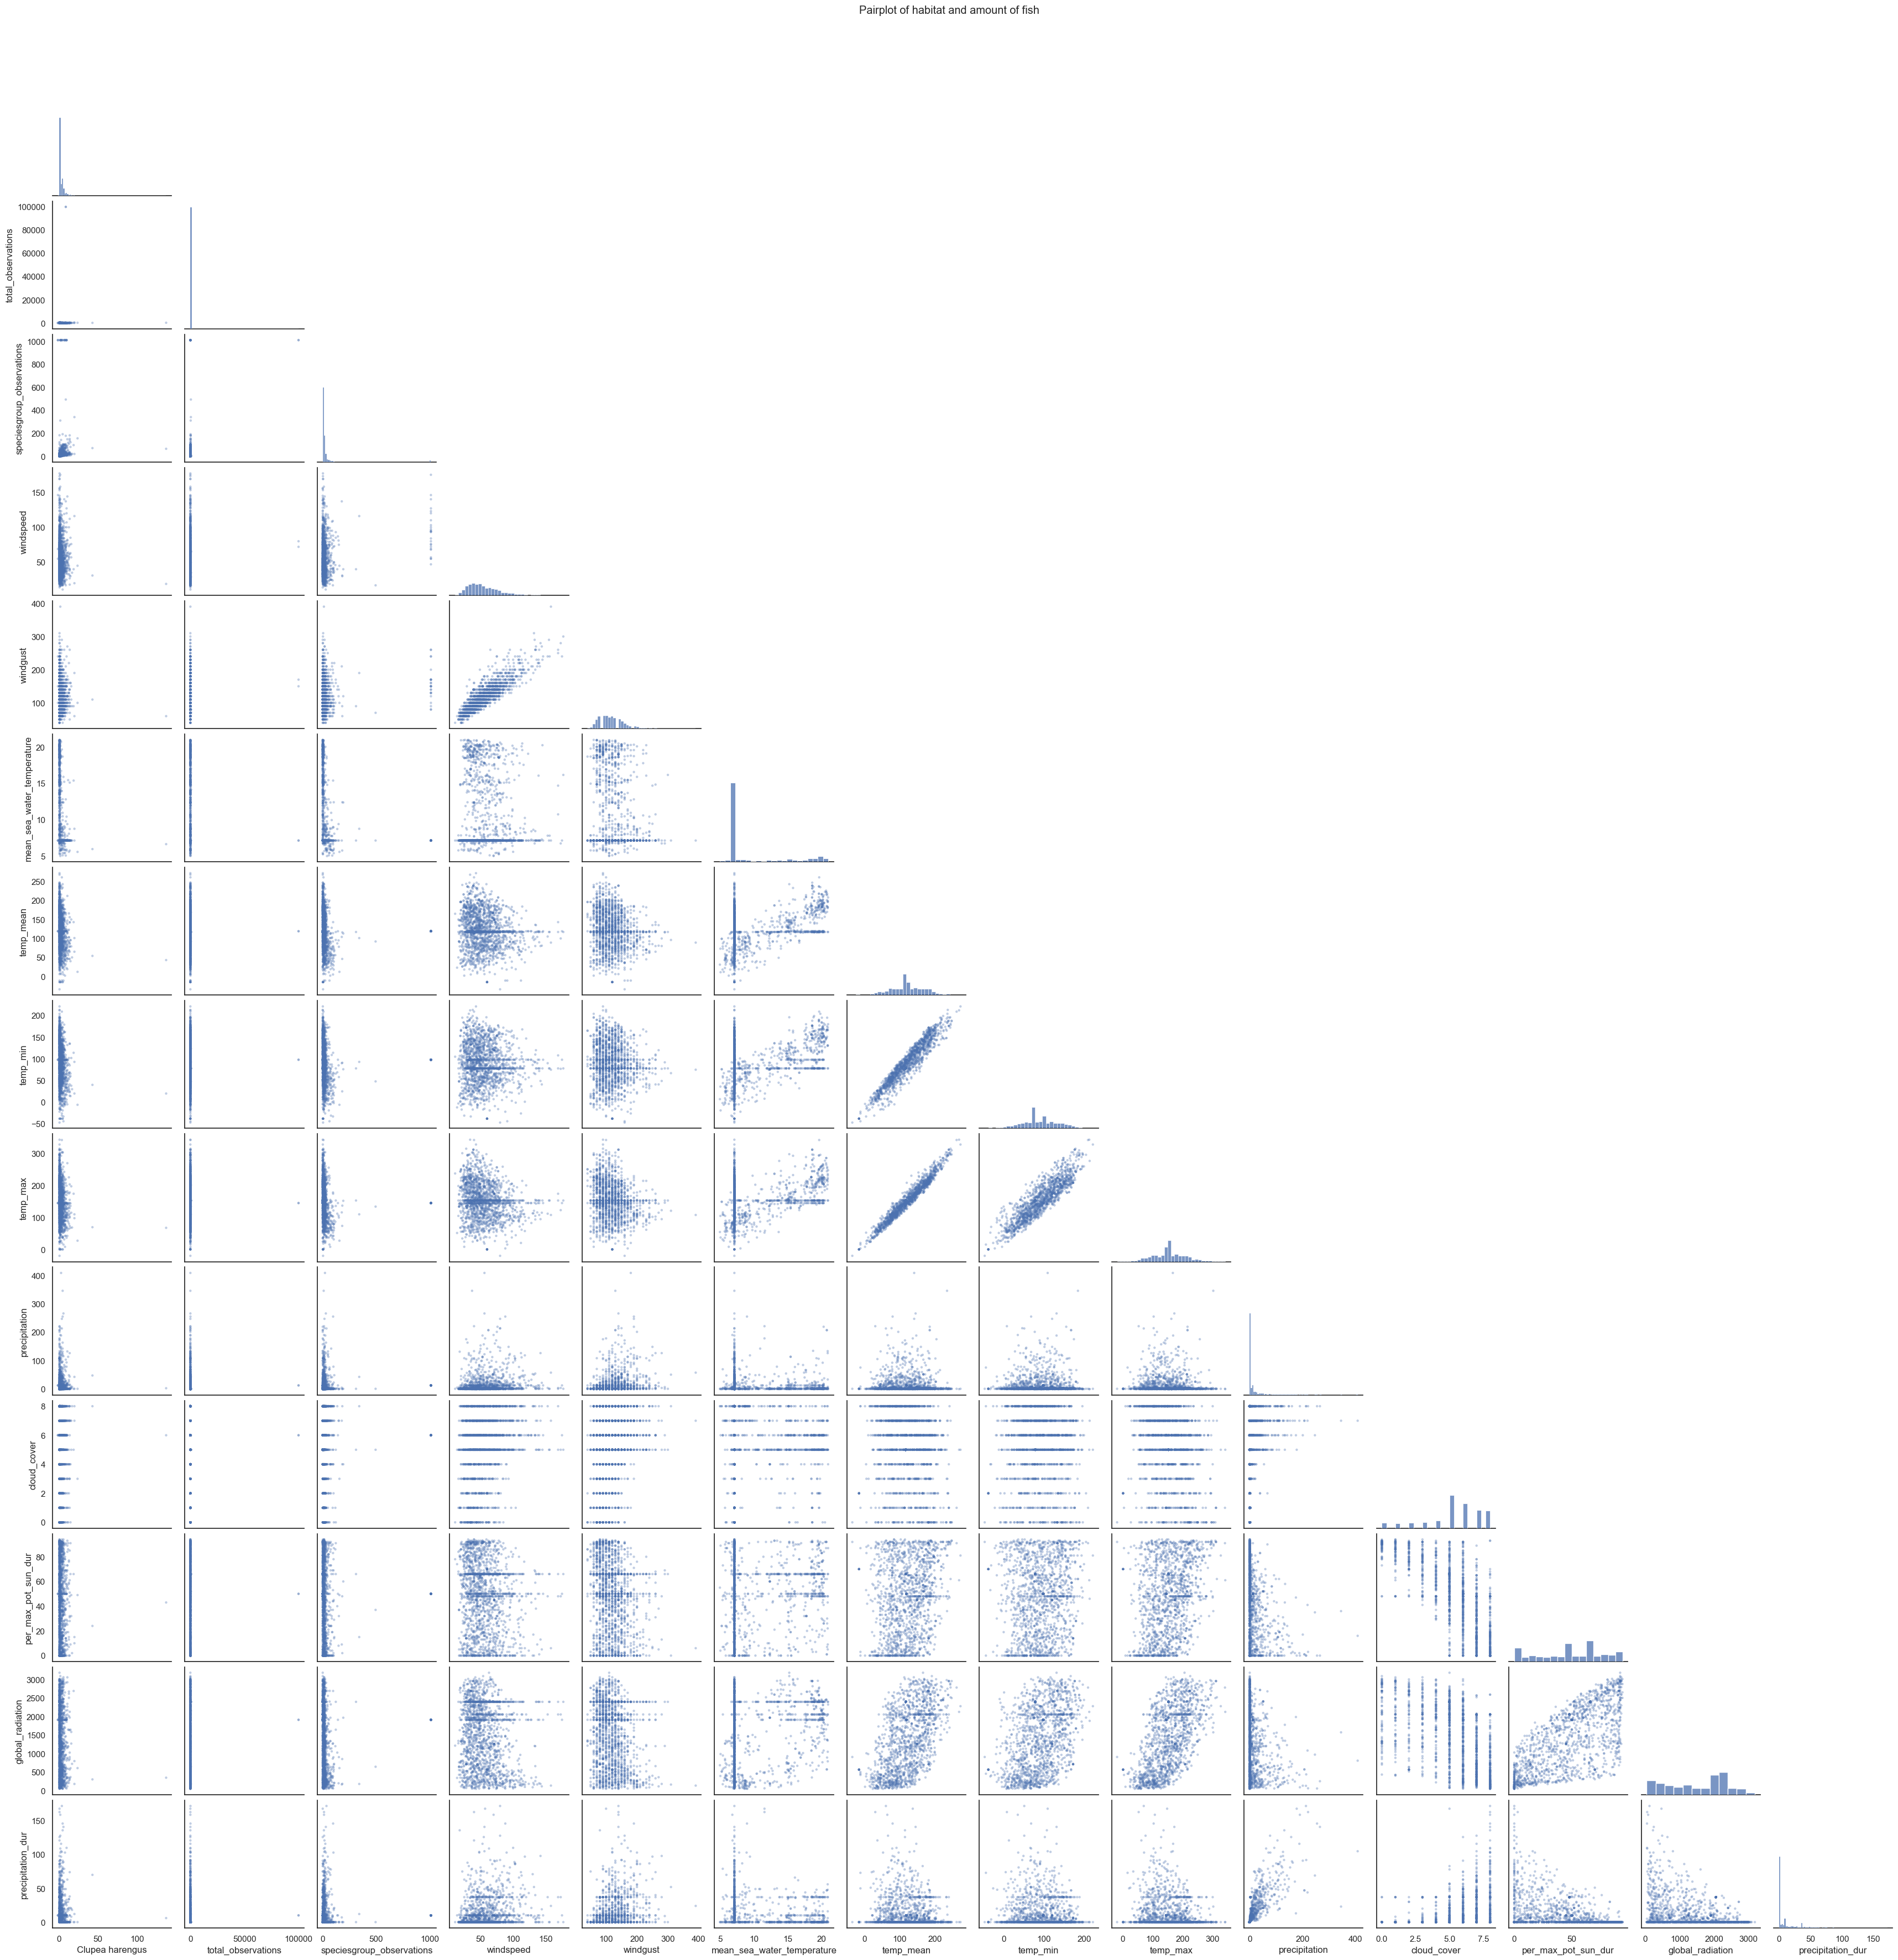

In [33]:
corr_cols = [
    'Clupea harengus',
    'total_observations',
    'speciesgroup_observations',
    'windspeed',
    'windgust',
    'mean_sea_water_temperature',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',
    'global_radiation',
    'precipitation_dur'
]

pair_df = (
    df_merged_ch[corr_cols]
    .dropna()
    .sample(n=min(10000, len(df_merged_ch[corr_cols].dropna())), random_state=42)
)

sns.set_theme(style="white")
g = sns.pairplot(
    pair_df,
    corner=True,
    plot_kws={"s": 10, "alpha": 0.35, "edgecolor": "none"},
    diag_kws={"fill": True}
)

g.figure.suptitle("Pairplot of habitat and amount of fish", y=1.02)
plt.show()

---

## Data Preparation

In [ ]:
cols_to_drop = [
    'agricultural',
    'wetland',
    'windspeed',
    'windgust',
    'precipitation',
    'cloud_cover',
    'per_max_pot_sun_dur',
    'precipitation_dur',
    'vector_mean_direction_degrees',
    'vector_mean_windspeed',
    'Date',
    'station_distance_km',
    'Station',
    'nearest_station'
]

df_merged_coastal_marine = df_merged_coastal_marine.drop(columns=cols_to_drop, errors='ignore')
df_merged_coastal_marine.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 19 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   decimalLatitude             float64       
 1   decimalLongitude            float64       
 2   eventDate                   datetime64[us]
 3   total_observations          float64       
 4   speciesgroup_observations   int64         
 5   Clupea harengus             float64       
 6   built                       float64       
 7   coast                       float64       
 8   forest                      float64       
 9   other                       float64       
 10  sand/heather                float64       
 11  water                       float64       
 12  main_habitat                str           
 13  temp_mean                   float64       
 14  temp_min                    float64       
 15  temp_max                    float64       
 16  sun_dur                    

In [ ]:
df_merged_coastal_marine = df_merged_coastal_marine[df_merged_coastal_marine['Clupea harengus'] <= 40]

In [46]:
df_merged_coastal_marine = df_merged_coastal_marine[df_merged_coastal_marine['total_observations'] >= 1]

In [47]:
df_merged_coastal_marine.info()

<class 'pandas.DataFrame'>
Index: 1479859 entries, 426626 to 12558729
Data columns (total 33 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   decimalLatitude                1479859 non-null  float64       
 1   decimalLongitude               1479859 non-null  float64       
 2   eventDate                      1479859 non-null  datetime64[us]
 3   total_observations             1479859 non-null  float64       
 4   speciesgroup_observations      1479859 non-null  int64         
 5   Clupea harengus                1479859 non-null  float64       
 6   agricultural                   1479859 non-null  float64       
 7   built                          1479859 non-null  float64       
 8   coast                          1479859 non-null  float64       
 9   forest                         1479859 non-null  float64       
 10  other                          1479859 non-null  float64       


---

## Modelling

**Baseline classification model**

**Improved classification model**

In [51]:
df_model = df_merged_coastal_marine.copy()

df_model['presence_ch'] = (df_model['Clupea harengus'] > 0).astype(int)

df_model['eventDate'] = pd.to_datetime(df_model['eventDate'])
df_model['year'] = df_model['eventDate'].dt.year
df_model['month'] = df_model['eventDate'].dt.month
df_model['dayofyear'] = df_model['eventDate'].dt.dayofyear

df_model = pd.get_dummies(df_model, columns=['main_habitat'], drop_first=True)

df_full = df_model.copy()

present = df_full[df_full['presence_ch'] == 1]
absent = df_full[df_full['presence_ch'] == 0]

ratio = 5
absent_down = absent.sample(
    n=min(len(absent), ratio * len(present)),
    random_state=42
)

df_train_balanced = pd.concat([present, absent_down]).sample(frac=1, random_state=42)

feature_cols = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'built', 'coast', 'forest', 'other', 'sand/heather', 'water',
    'temp_mean', 'temp_min', 'temp_max',
    'sun_dur', 'global_radiation',
    'mean_sea_water_temperature',
    'year', 'month', 'dayofyear',
] + [c for c in df_full.columns if c.startswith('main_habitat_')]

X_train = df_train_balanced[feature_cols]
y_train = df_train_balanced['presence_ch']

X_test = df_full[feature_cols]
y_test = df_full['presence_ch']

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=3,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [5, 7, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=3,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best RF params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

rf_best = grid.best_estimator_

y_proba = rf_best.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, pos_label=1))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", best_f1)

y_pred_best = (y_proba >= best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

importances = pd.Series(
    rf_best.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importances.head(20))

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best RF params: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 150}
Best CV F1: 0.8170069049011852
Best threshold: 0.9500000000000001
Best F1 score: 0.577995709469813
[[1477539     362]
 [   1015     943]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1477901
           1       0.72      0.48      0.58      1958

    accuracy                           1.00   1479859
   macro avg       0.86      0.74      0.79   1479859
weighted avg       1.00      1.00      1.00   1479859

speciesgroup_observations     0.284245
coast                         0.122919
total_observations            0.097063
main_habitat_coast            0.068558
built                         0.046486
water                         0.044674
year                          0.043939
other                         0.037550
mean_sea_water_temperature    0.036277
forest                        0.030273
deci

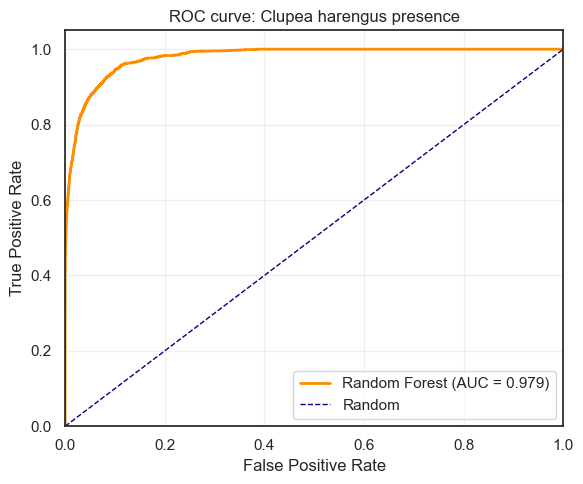

In [52]:
y_proba = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve: Clupea harengus presence')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Baseline regression model**

**Improved regression model**

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

df_reg = df_merged_coastal_marine.copy()
df_reg = df_reg[df_reg['Clupea harengus'] > 0].copy()

df_reg['eventDate'] = pd.to_datetime(df_reg['eventDate'])
df_reg['year'] = df_reg['eventDate'].dt.year
df_reg['month'] = df_reg['eventDate'].dt.month
df_reg['dayofyear'] = df_reg['eventDate'].dt.dayofyear

df_reg = pd.get_dummies(df_reg, columns=['main_habitat'], drop_first=True)

feature_cols_reg = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'built', 'coast', 'forest', 'other', 'sand/heather', 'water',
    'temp_mean', 'temp_min', 'temp_max',
    'sun_dur', 'global_radiation',
    'mean_sea_water_temperature',
    'year', 'month', 'dayofyear',
] + [c for c in df_reg.columns if c.startswith('main_habitat_')]

X_reg = df_reg[feature_cols_reg]
y_reg = df_reg['Clupea harengus']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

rf_base_reg = RandomForestRegressor(
    random_state=42, 
    n_jobs=3
)

param_grid_reg = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [5, 7, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

grid_reg = GridSearchCV(
    estimator=rf_base_reg,
    param_grid=param_grid_reg,
    scoring='neg_mean_squared_error',
    cv=cv_reg,
    n_jobs=3,
    verbose=1
)

grid_reg.fit(X_train_reg, y_train_reg)

print("Best RF Regressor params:", grid_reg.best_params_)

rf_best_reg = grid_reg.best_estimator_

y_pred_reg = rf_best_reg.predict(X_test_reg)

rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print("RMSE on test set:", rmse)
print("MAE on test set:", mae)

importances_reg = pd.Series(
    rf_best_reg.feature_importances_, 
    index=feature_cols_reg
).sort_values(ascending=False)

print(importances_reg.head(15))

Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best RF Regressor params: {'max_depth': 15, 'min_samples_leaf': 10, 'n_estimators': 50}
RMSE on test set: 2.0422827806990496
MAE on test set: 1.1439152209710954
speciesgroup_observations     0.535243
year                          0.100435
total_observations            0.071105
dayofyear                     0.057469
temp_max                      0.051983
global_radiation              0.043147
forest                        0.037721
mean_sea_water_temperature    0.027275
temp_min                      0.023461
sun_dur                       0.017279
built                         0.010929
temp_mean                     0.008619
decimalLongitude              0.004297
water                         0.003761
month                         0.003069
dtype: float64


**High Gradient Boosting Regressor**

In [54]:
hgb_poisson = HistGradientBoostingRegressor(
    loss='poisson',
    max_iter=200,
    max_depth=10,
    random_state=42
)

hgb_poisson.fit(X_train_reg, y_train_reg)
y_pred_pois = hgb_poisson.predict(X_test_reg)

print("MAE (Poisson):", mean_absolute_error(y_test_reg, y_pred_pois))
print("RMSE (Poisson):", root_mean_squared_error(y_test_reg, y_pred_pois))

MAE (Poisson): 1.09037595969952
RMSE (Poisson): 2.0383633982595857
